### Load all datasets

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_squared_log_error
warnings.filterwarnings('ignore')

DATA = '..\Data\store-sales-time-series-forecasting'

train    = pd.read_csv(f'{DATA}/train.csv', parse_dates=['date'])
stores   = pd.read_csv(f'{DATA}/stores.csv')
oil      = pd.read_csv(f'{DATA}/oil.csv', parse_dates=['date'])
holidays = pd.read_csv(f'{DATA}/holidays_events.csv', parse_dates=['date'])
tx       = pd.read_csv(f'{DATA}/transactions.csv', parse_dates=['date'])

### Health check

In [2]:
datasets = {'train': train, 'stores': stores,
            'oil': oil, 'holidays': holidays, 'transactions': tx}

for name, df in datasets.items():
    print(f"\n{'='*50}\n {name.upper()}\n{'='*50}")
    print(f"  Shape        : {df.shape[0]:>8,} rows × {df.shape[1]} columns")
    print(f"  Columns      : {df.columns.tolist()}")
    print(f"  Nulls        : {df.isnull().sum().sum()} total missing values")
    print(f"  Memory usage : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
    if 'date' in df.columns:
        print(f"  Date range   : {df['date'].min().date()} → {df['date'].max().date()}")


 TRAIN
  Shape        : 3,000,888 rows × 6 columns
  Columns      : ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']
  Nulls        : 0 total missing values
  Memory usage : 285.5 MB
  Date range   : 2013-01-01 → 2017-08-15

 STORES
  Shape        :       54 rows × 5 columns
  Columns      : ['store_nbr', 'city', 'state', 'type', 'cluster']
  Nulls        : 0 total missing values
  Memory usage : 0.0 MB

 OIL
  Shape        :    1,218 rows × 2 columns
  Columns      : ['date', 'dcoilwtico']
  Nulls        : 43 total missing values
  Memory usage : 0.0 MB
  Date range   : 2013-01-01 → 2017-08-31

 HOLIDAYS
  Shape        :      350 rows × 6 columns
  Columns      : ['date', 'type', 'locale', 'locale_name', 'description', 'transferred']
  Nulls        : 0 total missing values
  Memory usage : 0.1 MB
  Date range   : 2012-03-02 → 2017-12-26

 TRANSACTIONS
  Shape        :   83,488 rows × 3 columns
  Columns      : ['date', 'store_nbr', 'transactions']
  Nulls        : 0 tota

### Fix oil nulls

In [3]:
print(f"Oil nulls before: {oil['dcoilwtico'].isnull().sum()}")
oil['dcoilwtico'] = oil['dcoilwtico'].ffill().bfill()
print(f"Oil nulls after : {oil['dcoilwtico'].isnull().sum()}")

Oil nulls before: 43
Oil nulls after : 0


### Sales vs oil chart

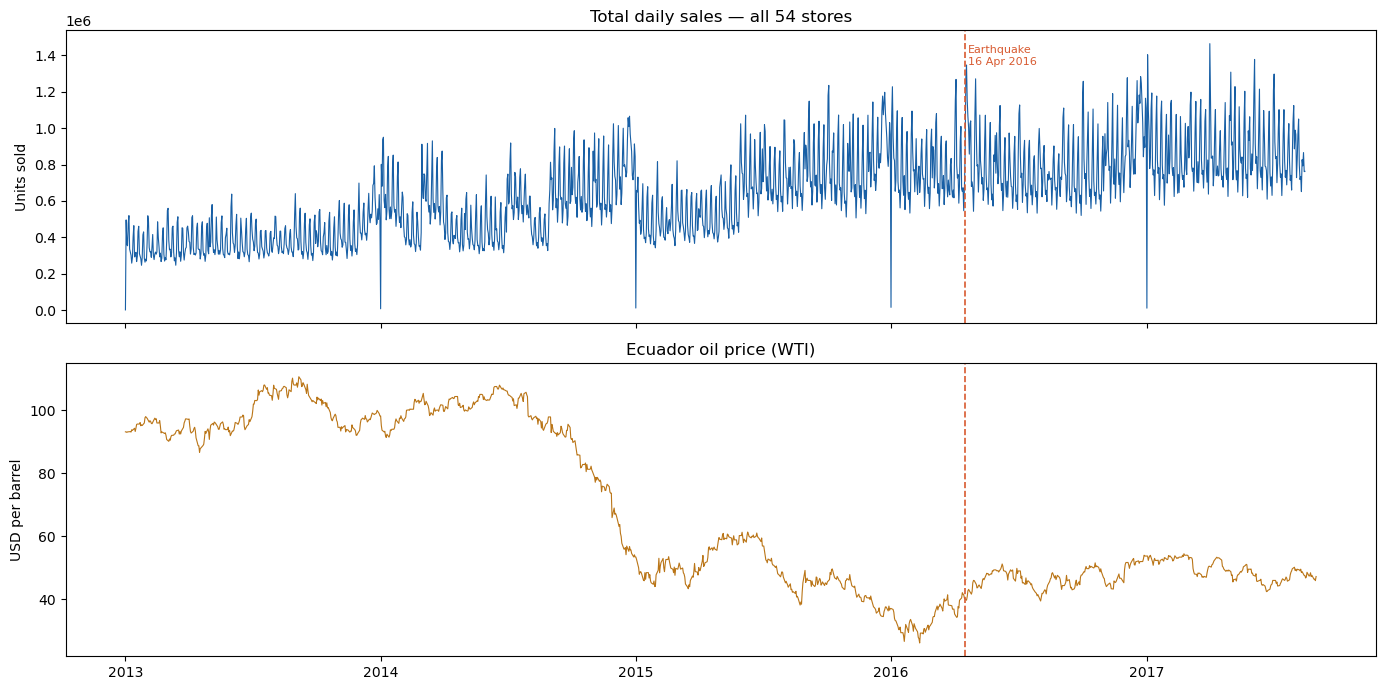

Total sales     : 1,073,644,952 units
Zero-sales rows : 939,130 (31.3%)
Max single day  : 1,463,084 on 2017-04-01


In [5]:
daily = train.groupby('date')['sales'].sum().reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(daily['date'], daily['sales'], color='#185FA5', linewidth=0.8)
axes[0].set_title('Total daily sales — all 54 stores')
axes[0].set_ylabel('Units sold')
axes[0].axvline(pd.Timestamp('2016-04-16'), color='#D85A30', linewidth=1.2, linestyle='--')
axes[0].text(pd.Timestamp('2016-04-20'), daily['sales'].max()*0.92,
             'Earthquake\n16 Apr 2016', fontsize=8, color='#D85A30')

axes[1].plot(oil['date'], oil['dcoilwtico'], color='#BA7517', linewidth=0.8)
axes[1].set_title('Ecuador oil price (WTI)')
axes[1].set_ylabel('USD per barrel')
axes[1].axvline(pd.Timestamp('2016-04-16'), color='#D85A30', linewidth=1.2, linestyle='--')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
#plt.savefig('../charts/sales_vs_oil.png', dpi=150)
plt.show()

print(f"Total sales     : {train['sales'].sum():,.0f} units")
print(f"Zero-sales rows : {(train['sales']==0).sum():,} ({(train['sales']==0).mean():.1%})")
print(f"Max single day  : {daily['sales'].max():,.0f} on {daily.loc[daily['sales'].idxmax(),'date'].date()}")

### Family analysis

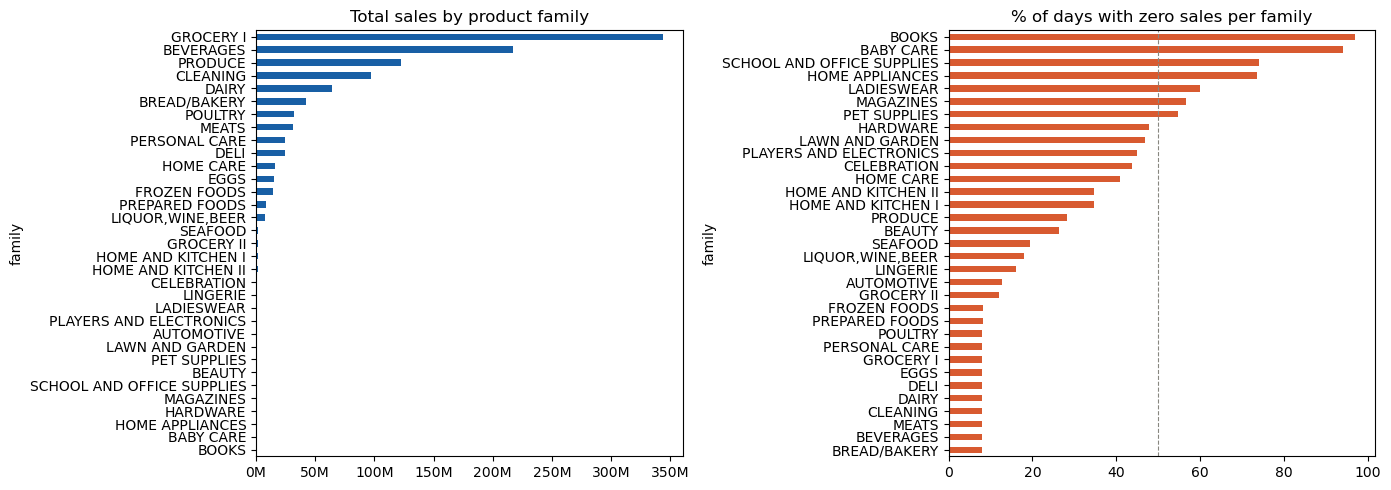

Top 5 families by volume:
family
GROCERY I    3.434627e+08
BEVERAGES    2.169545e+08
PRODUCE      1.227047e+08
CLEANING     9.752129e+07
DAIRY        6.448771e+07
Name: sales, dtype: float64

Hardest to forecast (most zero days):
family
BOOKS                         96.955001
BABY CARE                     94.131037
SCHOOL AND OFFICE SUPPLIES    74.082871
HOME APPLIANCES               73.517639
LADIESWEAR                    59.846485
Name: sales, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

family_sales = train.groupby('family')['sales'].sum().sort_values(ascending=True)
family_sales.plot(kind='barh', ax=axes[0], color='#185FA5',
                  title='Total sales by product family')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

zero_pct = (train.groupby('family')['sales']
            .apply(lambda x: (x==0).mean()*100)
            .sort_values(ascending=True))
zero_pct.plot(kind='barh', ax=axes[1], color='#D85A30',
              title='% of days with zero sales per family')
axes[1].axvline(50, color='#888780', linewidth=0.8, linestyle='--')

plt.tight_layout()
#plt.savefig('../charts/family_analysis.png', dpi=150)
plt.show()

print("Top 5 families by volume:")
print(family_sales.sort_values(ascending=False).head())
print("\nHardest to forecast (most zero days):")
print(zero_pct.sort_values(ascending=False).head())

### Merge all sources

In [8]:
# Store metadata
df = train.merge(stores, on='store_nbr', how='left')

# Oil price
df = df.merge(oil, on='date', how='left')
df = df.sort_values('date')
df['dcoilwtico'] = df['dcoilwtico'].ffill()

# National holidays
national_hols = (holidays[holidays['locale'] == 'National']
                 [['date']].drop_duplicates())
national_hols['is_holiday'] = 1
df = df.merge(national_hols, on='date', how='left')
df['is_holiday'] = df['is_holiday'].fillna(0).astype(int)

# Lagged transactions (footfall from last week)
tx_lagged = tx.copy()
tx_lagged['date'] = tx_lagged['date'] + pd.Timedelta(days=7)
tx_lagged = tx_lagged.rename(columns={'transactions': 'tx_lag7'})
df = df.merge(tx_lagged, on=['date', 'store_nbr'], how='left')
df['tx_lag7'] = df.groupby('store_nbr')['tx_lag7'].transform(
    lambda x: x.fillna(x.median()))

print(f"Merged shape : {df.shape}")
print(f"Nulls        :\n{df.isnull().sum()}")

Merged shape : (3000888, 13)
Nulls        :
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
city           0
state          0
type           0
cluster        0
dcoilwtico     0
is_holiday     0
tx_lag7        0
dtype: int64


###  Engineer features

In [9]:
df = df.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

# Calendar
df['day_of_week']  = df['date'].dt.dayofweek
df['month']        = df['date'].dt.month
df['year']         = df['date'].dt.year
df['day_of_month'] = df['date'].dt.day
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
df['is_month_end'] = df['date'].dt.is_month_end.astype(int)

# Lag features
grp = df.groupby(['store_nbr', 'family'])['sales']
df['lag_7']   = grp.shift(7)
df['lag_14']  = grp.shift(14)
df['lag_28']  = grp.shift(28)
df['lag_364'] = grp.shift(364)

# Rolling averages
df['roll_7_mean']  = grp.shift(1).rolling(7).mean()
df['roll_28_mean'] = grp.shift(1).rolling(28).mean()
df['roll_7_std']   = grp.shift(1).rolling(7).std()

# Promotion features
promo_grp = df.groupby(['store_nbr', 'family'])['onpromotion']
df['promo_lag_7']   = promo_grp.shift(7)
df['promo_roll_4w'] = promo_grp.shift(1).rolling(28).mean()

# Encodings
df['store_type_enc'] = df['type'].map({'A':1,'B':2,'C':3,'D':4,'E':5})
df['family_enc']     = df['family'].astype('category').cat.codes

feature_cols = [c for c in df.columns if c not in
                ['id','date','sales','city','state','type','family']]
print(f"Features ready: {len(feature_cols)}")
print(f"Shape         : {df.shape}")

# Save for modelling notebook
df.to_parquet('../Data/df_featured.parquet', index=False)
print("Saved to df_featured.parquet")

Features ready: 24
Shape         : (3000888, 31)
Saved to df_featured.parquet


### Train/validation split

In [12]:
FEATURES = [
    'store_nbr', 'family_enc', 'onpromotion', 'cluster',
    'dcoilwtico', 'is_holiday', 'tx_lag7',
    'day_of_week', 'month', 'year', 'day_of_month',
    'week_of_year', 'is_weekend', 'is_month_end',
    'lag_7', 'lag_14', 'lag_28', 'lag_364',
    'roll_7_mean', 'roll_28_mean', 'roll_7_std',
    'promo_lag_7', 'promo_roll_4w', 'store_type_enc'
]

df_model = df.dropna(subset=FEATURES).copy()
df_model['sales'] = df_model['sales'].clip(lower=0)

SPLIT_DATE = '2017-05-01'
train_df = df_model[df_model['date'] <  SPLIT_DATE]
valid_df = df_model[df_model['date'] >= SPLIT_DATE]

X_tr, y_tr = train_df[FEATURES], np.log1p(train_df['sales'])
X_va, y_va = valid_df[FEATURES], np.log1p(valid_df['sales'])

print(f"Train : {len(X_tr):,} rows  ({train_df['date'].min().date()} → {train_df['date'].max().date()})")
print(f"Valid : {len(X_va):,} rows  ({valid_df['date'].min().date()} → {valid_df['date'].max().date()})")

Train : 2,161,566 rows  (2014-01-01 → 2017-04-30)
Valid : 190,674 rows  (2017-05-01 → 2017-08-15)


### Train LightGBM

In [15]:
model = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.05, num_leaves=255,
    min_child_samples=20, feature_fraction=0.8,
    bagging_fraction=0.8, bagging_freq=1,
    objective='regression_l1', random_state=42, n_jobs=-1
)

model.fit(X_tr, y_tr,
          eval_set=[(X_va, y_va)],
          callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)])

preds   = np.expm1(model.predict(X_va)).clip(0)
actuals = valid_df['sales'].clip(0)
rmsle   = np.sqrt(mean_squared_log_error(actuals, preds))

print(f"\nBest iteration : {model.best_iteration_}")
print(f"Validation RMSLE: {rmsle:.4f}")

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0 will be ignored. Current value: bagging_freq=1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.077498 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3192
[LightGBM] [Info] Number of data points in

### Feature importance

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\KMosala\\OneDrive - Pepkor\\Desktop\\WorkInProgress\\Studies\\charts\\feature_importance.png'

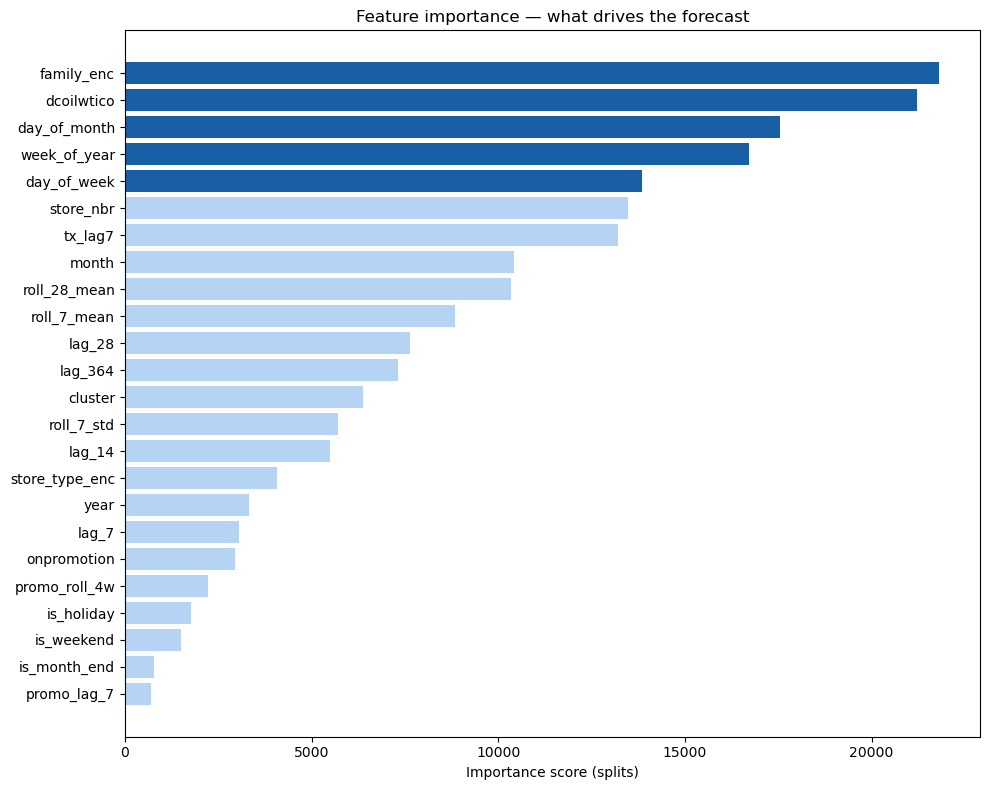

In [16]:
fi = (pd.DataFrame({'feature': FEATURES,
                    'importance': model.feature_importances_})
      .sort_values('importance', ascending=True))

colors = ['#185FA5' if i >= len(fi)-5 else '#B5D4F4' for i in range(len(fi))]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(fi['feature'], fi['importance'], color=colors)
ax.set_title('Feature importance — what drives the forecast')
ax.set_xlabel('Importance score (splits)')
plt.tight_layout()
plt.savefig('../charts/feature_importance.png', dpi=150)
plt.show()

### Per-family accuracy

In [17]:
valid_df = valid_df.copy()
valid_df['pred'] = preds

family_rmsle = {}
for family, grp in valid_df.groupby('family'):
    try:
        score = np.sqrt(mean_squared_log_error(
            grp['sales'].clip(0), grp['pred'].clip(0)))
        family_rmsle[family] = round(score, 4)
    except:
        family_rmsle[family] = None

scores = pd.Series(family_rmsle).dropna().sort_values()
print("5 easiest families:")
print(scores.head())
print("\n5 hardest families:")
print(scores.tail())

5 easiest families:
PRODUCE         0.1314
DAIRY           0.1378
BOOKS           0.1499
BREAD/BAKERY    0.1527
GROCERY I       0.1551
dtype: float64

5 hardest families:
SCHOOL AND OFFICE SUPPLIES    0.5195
GROCERY II                    0.5511
CELEBRATION                   0.5518
HARDWARE                      0.5529
LINGERIE                      0.6163
dtype: float64
